In [32]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, center_in_box
import os
import numpy as np
import freud
import matplotlib.pyplot as plt
import tqdm

In [33]:
lipids = 4096

In [34]:
def block_analysis(data, max_size = 10000):

    data = np.array(data)
    n = len(data)

    block_size = 10
    blocking_errors = []
    block_sizes = []

    while block_size <= min(max_size, n//2):

        n_blocks = n // block_size

        n_use = n_blocks * block_size
        data_trimmed = data[:n_use]

        blocks = data_trimmed.reshape(n_blocks, block_size)
        block_means = np.mean(blocks, axis=1)
        std_error = np.std(block_means, ddof=1) / np.sqrt(n_blocks)

        blocking_errors.append(std_error)
        block_sizes.append(block_size)

        block_size += 10

    plt.figure(figsize=(8, 5))
    plt.plot(block_sizes, blocking_errors, 'o-')
    plt.xlabel('Block Size')
    plt.ylabel('Standard Error')
    plt.grid(True)
    plt.title('Block Analysis')

    plt.show()
    
    return block_sizes, blocking_errors

In [35]:
def running_avg(lst):

    avg_lst = []
    std_lst = []

    for i in tqdm.tqdm(range(len(lst))):

       avg_lst.append(np.mean(lst[:i+1])) 
       std_lst.append(np.std(lst[:i+1]))

    avg_lst, std_lst = np.array(avg_lst), np.array(std_lst)

    plt.plot(avg_lst)

In [36]:
def force_and_radius(R):

    sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_and_force_{R}.dat"), skiprows=2, usecols=(1,2,3,4))
    sigma_xx, sigma_yy, sigma_zz, force_z = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2], sigma_data[:, 3]

    top_file = os.path.join(dir, f"setup/cylinder_{R}.data")
    traj_file = os.path.join(dir, f"tether_simulation/data/cylinder_sim_{R}.lammpstrj")

    u = mda.Universe(top_file, format="DATA", atom_style = "id resid type charge x y z")
    u.load_new(traj_file, format="LAMMPSDUMP", dt=0.005)

    radii = []

    lipid_atoms = u.select_atoms(f"not type 4")

    for ts in u.trajectory:

        com = lipid_atoms.center_of_mass()

        positions = lipid_atoms.positions

        x = positions[:, 0] - com[0]
        y = positions[:, 1] - com[1]

        r = np.sqrt(x**2 + y**2)

        radii.append(np.mean(r))

    radius = np.mean(radii)

    radii = np.array(radii)

    force = np.abs(np.mean(force_z))

    kappa = force*radius/(2*np.pi)

    print(f"Values for R = {R}")
    print(f"Force {force}")
    print(f"sigma_zz {np.mean(sigma_zz)}")
    print(f"sigma_xx {np.mean(sigma_xx)}")
    print(f"sigma_yy {np.mean(sigma_yy)}")

    print(f"kappa = {kappa}")

    return force, radius

In [37]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

rads = ["8", "10"]
results = []

for R in rads:

    results.append(force_and_radius(R))



Values for R = 8
Force 1.684659383512853
sigma_zz -0.0008449214487401126
sigma_xx -0.00029134961055659675
sigma_yy 0.0002913496105585746
kappa = 3.892361351652448
Values for R = 10
Force 0.8528320620565382
sigma_zz -0.00034156682065002343
sigma_xx 0.0001853543668021446
sigma_yy -0.00018535436682034478
kappa = 2.5101536199096954


<ErrorbarContainer object of 3 artists>

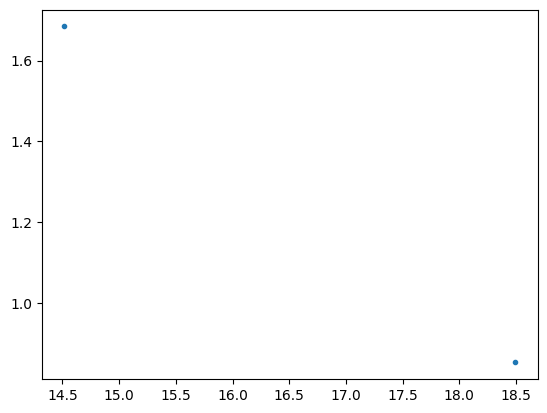

In [40]:
force = [t[0] for t in results]
radii = [t[1] for t in results]

plt.errorbar(radii, force, fmt=".")

In [47]:
for R in [6,8,10]:
    sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_and_force_{R}.dat"), skiprows=2, usecols=(1,2,3,4))
    sigma_xx, sigma_yy, sigma_zz, force_z = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2], sigma_data[:, 3]

    print(np.mean(force_z))

-0.06945954186952825
-1.684659383512853
-0.8528320620565382
